In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv("ecommerce_dataset_updated.csv")
eda_df = df.copy()

In [64]:
eda_df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [65]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [66]:
eda_df.drop(columns=['User_ID' ,'Product_ID'] , axis=1 , inplace=True)

In [67]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          3660 non-null   object 
 1   Price (Rs.)       3660 non-null   float64
 2   Discount (%)      3660 non-null   int64  
 3   Final_Price(Rs.)  3660 non-null   float64
 4   Payment_Method    3660 non-null   object 
 5   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 171.7+ KB


In [68]:
eda_df.describe()

,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [69]:
eda_df.isnull().sum()

Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

In [70]:
eda_df.duplicated().sum()

np.int64(0)

In [71]:
eda_df

,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,Toys,173.19,25,129.89,UPI,01-04-2024
4,Beauty,244.80,20,195.84,Net Banking,27-09-2024
...,...,...,...,...,...,...
3655,Beauty,486.79,0,486.79,UPI,14-05-2024
3656,Toys,212.87,15,180.94,Cash on Delivery,19-11-2024
3657,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-2024
3658,Electronics,447.66,30,313.36,UPI,21-05-2024


In [73]:
eda_df.groupby('Category')['Price (Rs.)'].sum()

Category
Beauty            127633.04
Books             138371.71
Clothing          139714.55
Electronics       125320.14
Home & Kitchen    136841.51
Sports            134481.99
Toys              130207.53
Name: Price (Rs.), dtype: float64

In [11]:
eda_df.groupby('Region')['Discounted_Price'].sum()

Region
Bangalore    2.303915e+08
Chennai      2.327410e+08
Delhi        2.338411e+08
Hyderabad    2.387178e+08
Jaipur       2.326528e+08
Kolkata      2.347654e+08
Mumbai       2.342426e+08
Pune         2.366762e+08
Name: Discounted_Price, dtype: float64

In [12]:
payment_counts = eda_df['Payment_Method'].value_counts()

payment_counts

Payment_Method
UPI            20212
Debit Card     20181
Net Banking    19949
COD            19881
Credit Card    19777
Name: count, dtype: int64

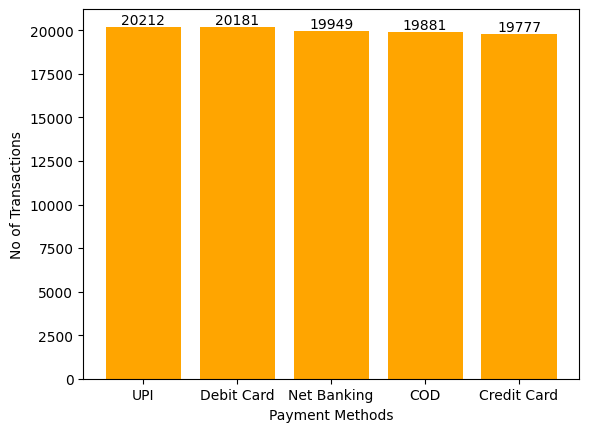

In [13]:
bar1 = plt.bar(payment_counts.index, payment_counts.values , color='orange')
plt.bar_label(bar1)
plt.xlabel('Payment Methods')
plt.ylabel('No of Transactions')
plt.show()

## All payment methods has almost equal number of transactions

In [14]:
revenue_per_method = eda_df.groupby('Payment_Method')['Discounted_Price'].sum()
revenue_per_method

Payment_Method
COD            3.720007e+08
Credit Card    3.716724e+08
Debit Card     3.802464e+08
Net Banking    3.735002e+08
UPI            3.766087e+08
Name: Discounted_Price, dtype: float64

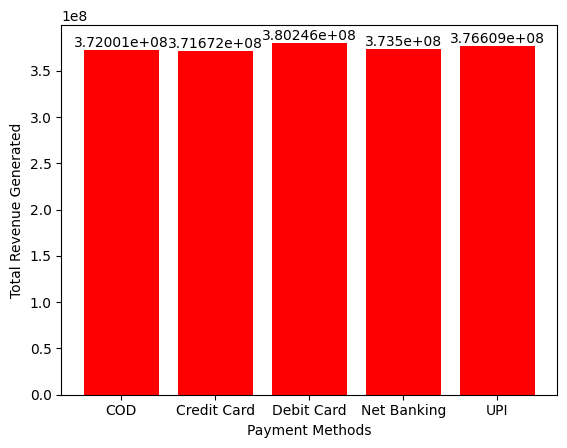

In [15]:
bar2 = plt.bar(revenue_per_method.index, revenue_per_method.values , color='red')
plt.bar_label(bar2)
plt.xlabel('Payment Methods')
plt.ylabel('Total Revenue Generated')
plt.show()

In [16]:
labelsAge = [f'{i} - {i+12}' for i in range(0, 61, 12)]
print(labelsAge)

['0 - 12', '12 - 24', '24 - 36', '36 - 48', '48 - 60', '60 - 72']


In [17]:
eda_df["Age_Group"] = pd.cut(eda_df.Age , labels=labelsAge, bins=range(0,80,12))

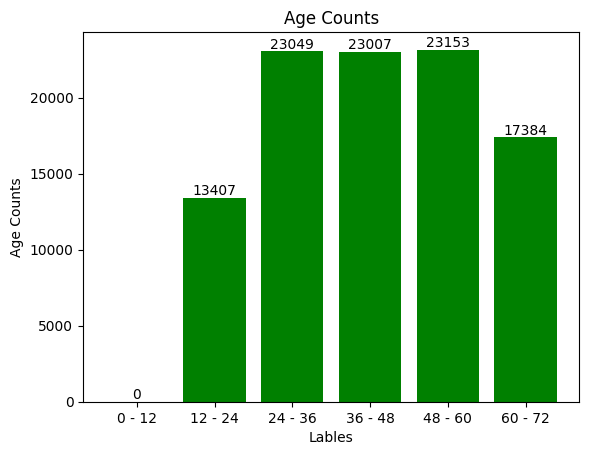

In [18]:
ageGroupBar = plt.bar(labelsAge , eda_df.Age_Group.value_counts().sort_index() , color='green')
plt.bar_label(ageGroupBar)
plt.xlabel("Lables")
plt.ylabel("Age Counts")
plt.title("Age Counts")
plt.show()

## Age groups from 24-60 are highly active while Age Group from 12-24 & 60-72 are slightly lower active

In [19]:
revenue_age_group = eda_df.groupby('Age_Group' , observed=True)['Revenue'].sum()
revenue_age_group

Age_Group
12 - 24    7.465896e+08
24 - 36    1.292378e+09
36 - 48    1.287402e+09
48 - 60    1.299661e+09
60 - 72    9.731375e+08
Name: Revenue, dtype: float64

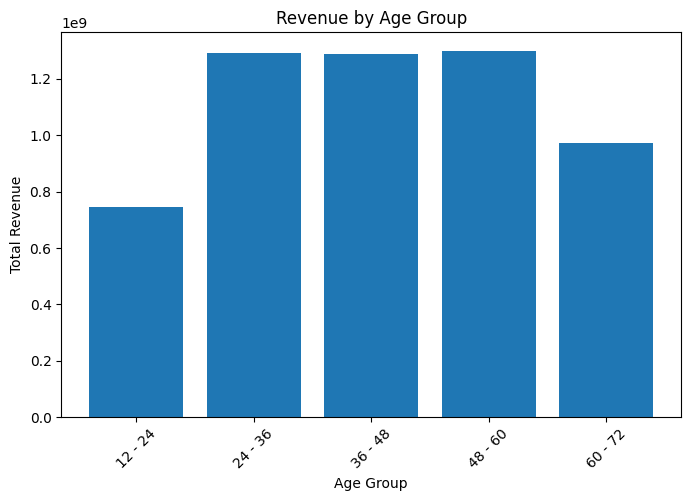

In [20]:
plt.figure(figsize=(8,5))
plt.bar(revenue_age_group.index.astype(str),
        revenue_age_group.values)

plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.title("Revenue by Age Group")
plt.xticks(rotation=45)
plt.show()

### 48–60 age group generates the highest revenue.
### 24–60 age range is the strongest customer segment.

In [22]:
revenue_by_gender = eda_df.groupby('Gender')['Revenue'].sum()
revenue_by_gender

Gender
Female    2.788682e+09
Male      2.697103e+09
Other     1.133828e+08
Name: Revenue, dtype: float64

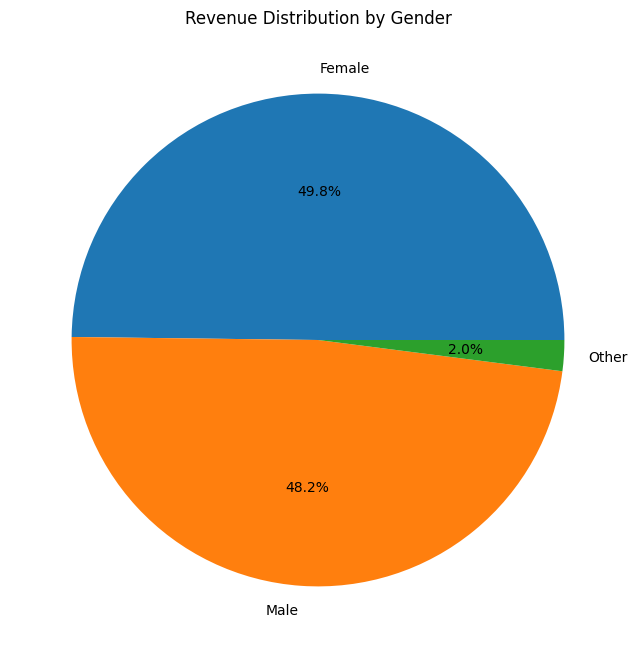

In [23]:
plt.figure(figsize=(8,8))

plt.pie(
    revenue_by_gender.values,
    labels=revenue_by_gender.index,
    autopct='%1.1f%%'
)

plt.title("Revenue Distribution by Gender")
plt.show()

In [28]:
eda_df.corr(numeric_only=True)

,Age,Price,Quantity,Discount_Percent,Rating,Delivery_Days,Returned,Prime_Member,Seller_Rating,Order_Month,Revenue,Discounted_Price
Age,1.000000,-0.002915,0.001700,-0.000707,-0.001697,-0.002688,-0.000506,0.002924,0.002097,0.001701,0.000752,-0.003095
Price,-0.002915,1.000000,-0.005443,-0.001927,0.002910,0.003160,0.001360,0.002638,0.000760,-0.001233,0.689759,0.930470
Quantity,0.001700,-0.005443,1.000000,-0.003755,-0.002941,-0.002871,-0.004431,0.000802,0.002739,-0.005087,0.566865,-0.003302
Discount_Percent,-0.000707,-0.001927,-0.003755,1.000000,0.002100,-0.002040,0.003345,-0.000039,-0.002905,-0.003613,-0.241062,-0.319363
Rating,-0.001697,0.002910,-0.002941,0.002100,1.000000,0.001794,0.006439,0.002876,0.001383,0.006376,-0.000515,0.001490
Delivery_Days,-0.002688,0.003160,-0.002871,-0.002040,0.001794,1.000000,-0.004145,-0.001642,-0.001325,-0.000608,0.000535,0.003852
Returned,-0.000506,0.001360,-0.004431,0.003345,0.006439,-0.004145,1.000000,0.005563,0.002802,-0.002025,-0.001021,0.000267
Prime_Member,0.002924,0.002638,0.000802,-0.000039,0.002876,-0.001642,0.005563,1.000000,-0.004092,0.001393,0.001110,0.002219
Seller_Rating,0.002097,0.000760,0.002739,-0.002905,0.001383,-0.001325,0.002802,-0.004092,1.000000,0.006533,0.003189,0.002191
Order_Month,0.001701,-0.001233,-0.005087,-0.003613,0.006376,-0.000608,-0.002025,0.001393,0.006533,1.000000,-0.005002,-0.000618


<Axes: >

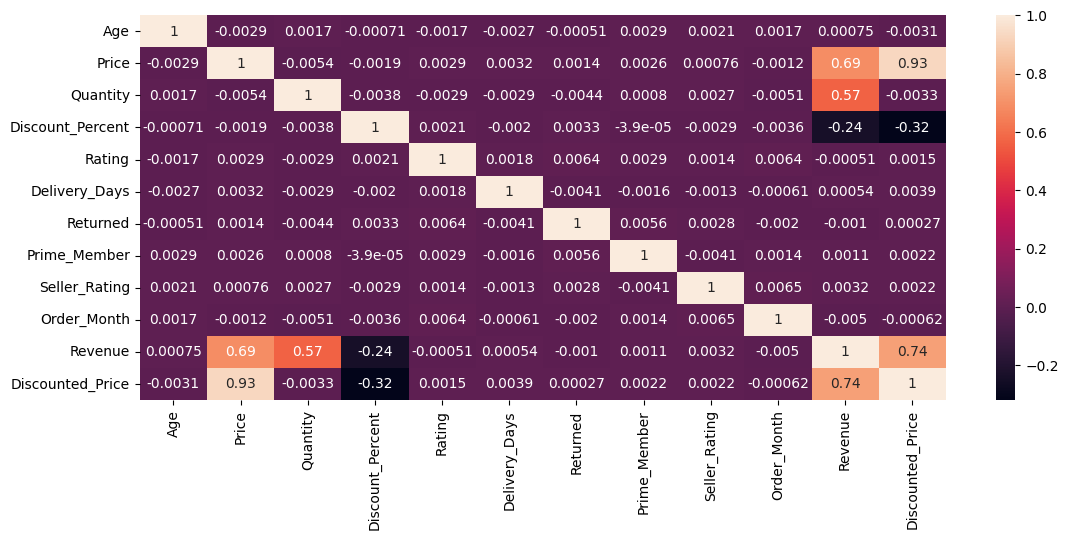

In [33]:
plt.figure(figsize=(13,5))
sns.heatmap(eda_df.corr(numeric_only=True) , annot=True)

In [38]:
category_by_revenue = eda_df.groupby('Product_Category')['Revenue'].sum()
category_by_revenue

Product_Category
Beauty         7.018730e+08
Books          6.987037e+08
Electronics    7.008641e+08
Fashion        7.022623e+08
Grocery        7.074417e+08
Home           7.071617e+08
Sports         7.058899e+08
Toys           6.749714e+08
Name: Revenue, dtype: float64

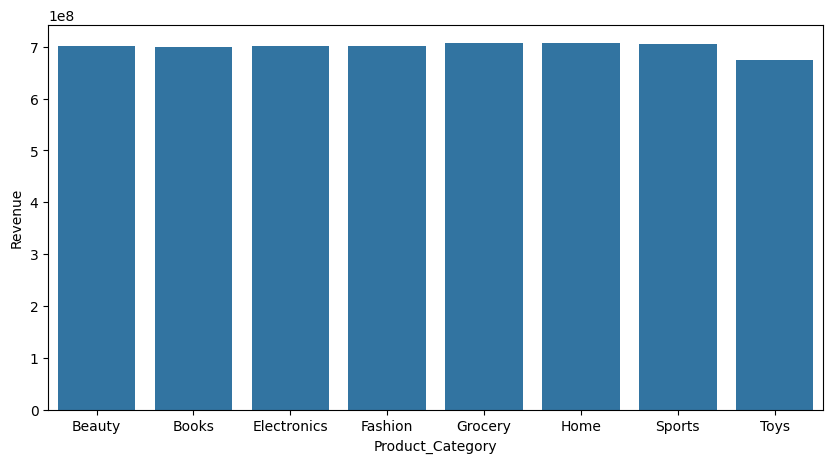

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(category_by_revenue)
plt.show()

In [48]:
eda_df.groupby('Product_Category')['Discount_Percent'].mean()

Product_Category
Beauty         25.025065
Books          25.222524
Electronics    24.976351
Fashion        25.096427
Grocery        24.845311
Home           24.971715
Sports         24.962279
Toys           25.243517
Name: Discount_Percent, dtype: float64

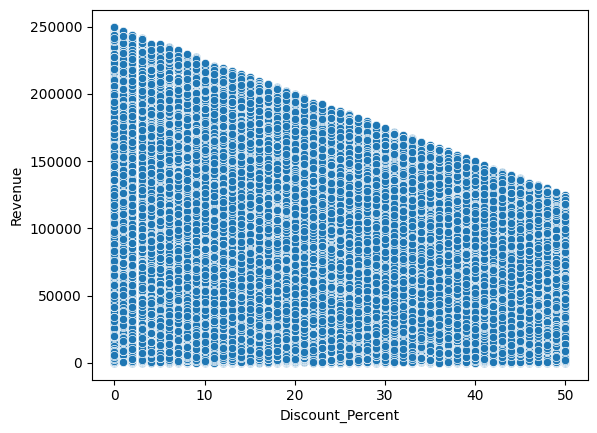

In [51]:
sns.scatterplot(
    data=eda_df,
    x='Discount_Percent',
    y='Revenue'
)
plt.show()

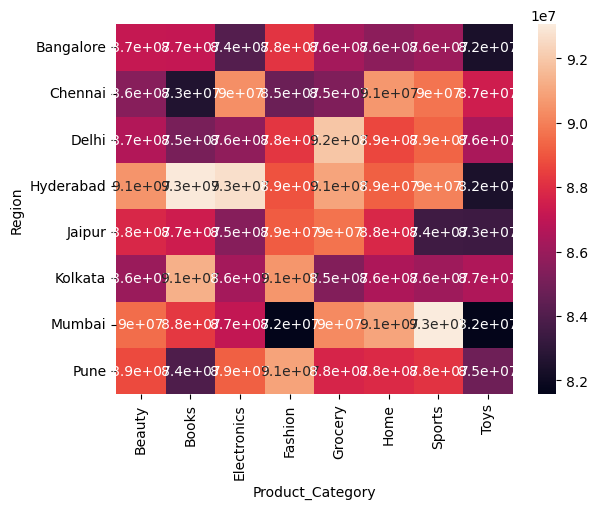

In [54]:
pivot = pd.pivot_table(
    eda_df,
    values='Revenue',
    index='Region',
    columns='Product_Category',
    aggfunc='sum'
)

sns.heatmap(pivot, annot=True)
plt.show()

In [57]:
eda_df.groupby('Product_Category')['Discounted_Price'].sum()

Product_Category
Beauty         2.354862e+08
Books          2.339347e+08
Electronics    2.355823e+08
Fashion        2.348414e+08
Grocery        2.358825e+08
Home           2.362991e+08
Sports         2.357641e+08
Toys           2.262380e+08
Name: Discounted_Price, dtype: float64

In [59]:
cat_rev = (
    eda_df.groupby('Product_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)
cat_rev

Product_Category
Grocery        7.074417e+08
Home           7.071617e+08
Sports         7.058899e+08
Fashion        7.022623e+08
Beauty         7.018730e+08
Electronics    7.008641e+08
Books          6.987037e+08
Toys           6.749714e+08
Name: Revenue, dtype: float64